In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV
import json
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

# Hàm Target Encoding có KFold
def target_encode_kfold(df, column, target, n_fold=5, alpha=5):
    """
    Performs target encoding with k-fold cross-validation to prevent data leakage.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataframe containing the data
    column : str
        The name of the categorical column to encode
    target : str
        The name of the target column
    n_fold : int, default=5
        Number of folds for cross-validation
    alpha : float, default=5
        Regularization parameter
        
    Returns:
    --------
    pandas Series
        The encoded values for the column
    """
    # Create a copy of the dataframe
    df_copy = df.copy()
    
    # Calculate the global mean
    global_mean = df_copy[target].mean()
    
    # Create the output Series
    encoded = pd.Series(index=df_copy.index)
    
    # Split the data into n_fold parts
    kf = KFold(n_splits=n_fold, shuffle=True, random_state=42)
    
    for train_idx, test_idx in kf.split(df_copy):
        # Calculate the mean target for each category in the training fold
        means = df_copy.iloc[train_idx].groupby(column)[target].agg(['mean', 'count'])
        
        # Apply regularization
        smoothed_means = ((means['mean'] * means['count']) + (global_mean * alpha)) / (means['count'] + alpha)
        
        # Map the means to the test fold
        encoded.iloc[test_idx] = df_copy.iloc[test_idx][column].map(smoothed_means)
    
    # Handle any categories that weren't seen in the training data (use global mean)
    encoded.fillna(global_mean, inplace=True)
    
    return encoded

In [2]:
# Bước 1: Đọc dữ liệu
train_file = '../../data/datasets/train_stratified_by_chip_model.csv'
test_file = '../../data/datasets/test_stratified_by_chip_model.csv'

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

# Các cột cần encoding và cột mục tiêu
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']
target_col = 'price'

# Lưu lại mean của các categorical features
encoding_means = {}
encoding_means_path = './datasets/encoding_means.json'


In [3]:
# Bước 2: Target Encoding
for col in categorical_cols:
    print(f"Encoding {col}...")
    train_df[f'{col}_encoded'] = target_encode_kfold(
        train_df, column=col, target=target_col, n_fold=5, alpha=10
    )
    # Lưu mean của từng category
    encoding_means[col] = train_df.groupby(col)[f'{col}_encoded'].mean().to_dict()

# Lưu encoding_means vào file JSON
with open(encoding_means_path, 'w') as f:
    json.dump(encoding_means, f)
print(f"Saved encoding means to ${encoding_means_path}")

# Áp dụng encoding cho tập test
for col in categorical_cols:
    test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())



Encoding chip_model...
Encoding brand...
Encoding screen_tech...
Encoding screen_resolution_k...
Saved encoding means to $./datasets/encoding_means.json


In [4]:
# Bước 3: Chuẩn bị dữ liệu
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
target = 'price'

X_train = train_df[features]
y_train = train_df[target_col]
X_test = test_df[features]
y_test = test_df[target_col]

In [5]:
# Bước 4: Tối ưu hóa siêu tham số
param_dist = {
    'n_estimators': [100, 300, 500, 600, 800],
    'learning_rate': [0.01, 0.005, 0.001],
    'max_depth': [3, 5, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

gb_base = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    gb_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    random_state=42
)

print("Tuning hyperparameters...")
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

print("✅ Best Hyperparameters:")
print(random_search.best_params_)

Tuning hyperparameters...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
✅ Best Hyperparameters:
{'subsample': 0.6, 'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 8, 'learning_rate': 0.01}


In [129]:
# Bước 6: Lưu model
print("Evaluating model...")
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Lưu model tốt nhất
print("Saving best model...")
joblib.dump(best_model, 'best_gb_model.pkl')
print("✅ Saved best model to 'best_gb_model.pkl'")

# Bước 7: Trực quan hóa loss trên tập train
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(best_model.train_score_) + 1), best_model.train_score_, label='Train Loss', color='blue')
plt.xlabel('Number of Estimators')
plt.ylabel('MSE')
plt.title('Train Loss Curve')
plt.legend()
plt.grid()
plt.show()

Test

In [7]:
import pandas as pd
import joblib
import json

# Đường dẫn đến file trọng số và encoding means
model_file = 'gradient_boosting_model.pkl'
encoding_means_file = './datasets/encoding_means.json'

# Tải mô hình đã lưu
model = joblib.load(model_file)
print("Model loaded successfully!")

# Tải encoding means
with open(encoding_means_file, 'r') as f:
    encoding_means = json.load(f)
print("Encoding means loaded successfully!")

# Đọc tập test
test_file = '../../data/datasets/test_stratified_by_chip_model.csv'
test_df = pd.read_csv(test_file)

# Các cột cần mã hóa
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']

# Áp dụng encoding cho tập test
for col in categorical_cols:
    test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(0)

# Các cột đặc trưng
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']

# Chuẩn bị dữ liệu
X_test = test_df[features]

# Dự đoán
y_pred = model.predict(X_test)

# Lưu kết quả dự đoán
test_df['predicted_price'] = y_pred
output_file = 'test_predictions.csv'
test_df.to_csv(output_file, index=False)
print(f"Predictions saved to {output_file}")

FileNotFoundError: [Errno 2] No such file or directory: 'gradient_boosting_model.pkl'

### 1. Trực quan hóa hiệu suất mô hình
- a. Biểu đồ so sánh giá trị thực tế và giá trị dự đoán
    - Mục đích: Để kiểm tra mức độ khớp giữa giá trị thực tế (y_test) và giá trị dự đoán (y_pred).
    - Cách thực hiện:

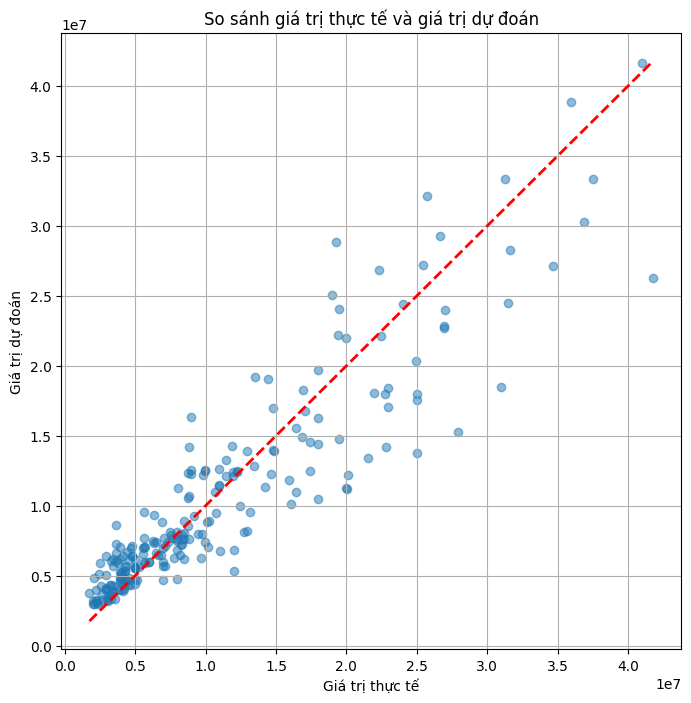

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Biểu đồ scatter giữa giá trị thực tế và giá trị dự đoán
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('So sánh giá trị thực tế và giá trị dự đoán')
plt.grid()
plt.show()

b. Biểu đồ phân phối sai số (Residual Plot)
- Mục đích: Để kiểm tra xem sai số có phân phối ngẫu nhiên hay không.
- Cách thực hiện:

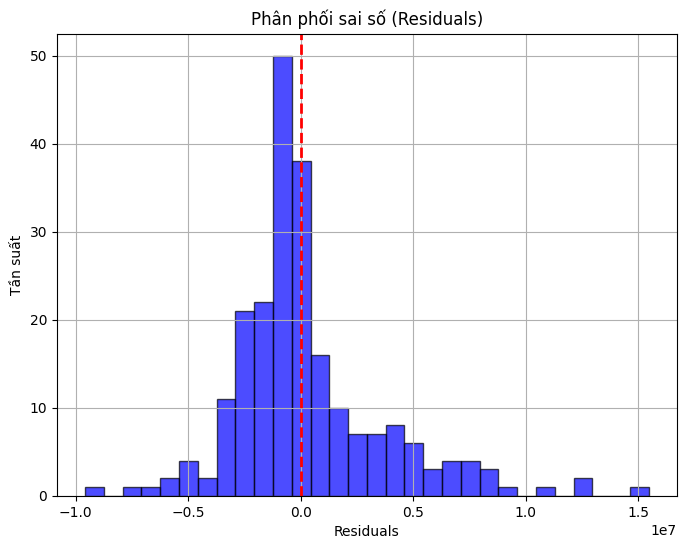

In [ ]:
# Tính residuals
residuals = y_test - y_pred

# Biểu đồ phân phối residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals')
plt.ylabel('Tần suất')
plt.title('Phân phối sai số (Residuals)')
plt.grid()
plt.show()

### 2. Trực quan hóa tầm quan trọng của đặc trưng (Feature Importance)
- Mục đích: Để hiểu đặc trưng nào đóng vai trò quan trọng nhất trong việc dự đoán.
- Cách thực hiện:

In [ ]:
# Lấy tầm quan trọng của đặc trưng từ mô hình
feature_importances = model.feature_importances_
feature_names = features

# Biểu đồ cột cho tầm quan trọng của đặc trưng
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances, color='skyblue')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.title('Tầm quan trọng của các đặc trưng')
plt.grid(axis='x')
plt.show()

### 3. Trực quan hóa mối quan hệ giữa đặc trưng và giá trị mục tiêu
- a. Biểu đồ scatter giữa đặc trưng quan trọng nhất và giá trị mục tiêu
    - Mục đích: Để kiểm tra mối quan hệ giữa đặc trưng quan trọng nhất và giá trị mục tiêu (price).
    - Cách thực hiện:

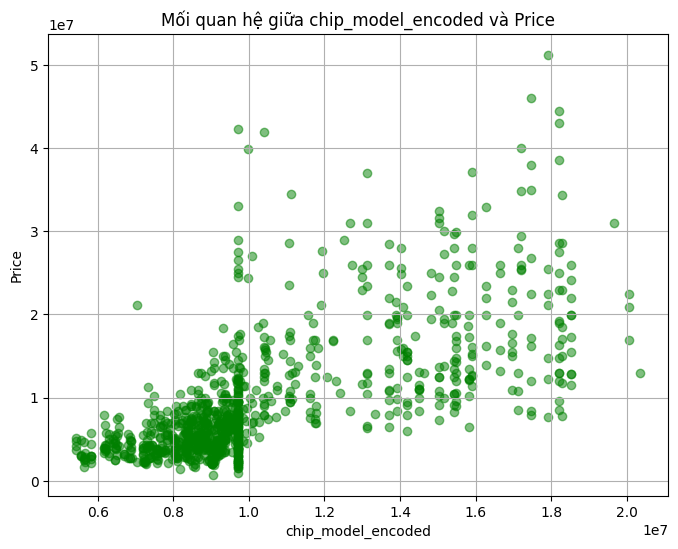

In [ ]:
# Chọn đặc trưng quan trọng nhất
most_important_feature = feature_names[np.argmax(feature_importances)]

# Biểu đồ scatter
plt.figure(figsize=(8, 6))
plt.scatter(train_df[most_important_feature], train_df[target], alpha=0.5, color='green')
plt.xlabel(most_important_feature)
plt.ylabel('Price')
plt.title(f'Mối quan hệ giữa {most_important_feature} và Price')
plt.grid()
plt.show()

### 4. Trực quan hóa phân phối giá trị thực tế và giá trị dự đoán
- Mục đích: Để kiểm tra xem phân phối của giá trị dự đoán có khớp với giá trị thực tế hay không.
- Cách thực hiện:

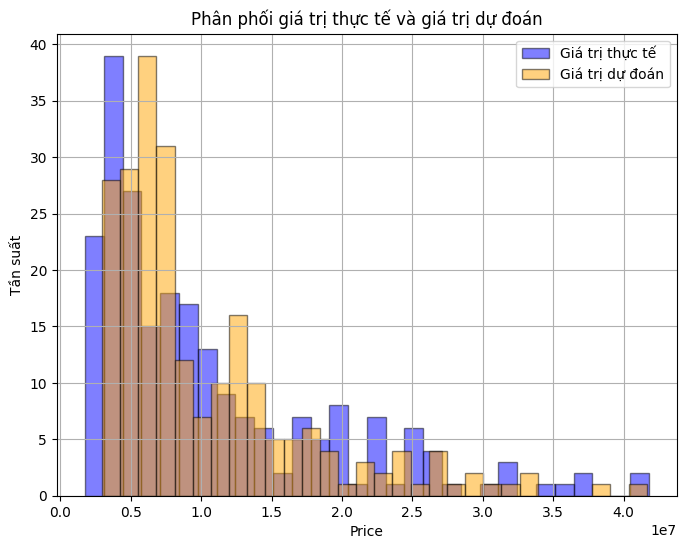

In [ ]:
# Biểu đồ phân phối giá trị thực tế và giá trị dự đoán
plt.figure(figsize=(8, 6))
plt.hist(y_test, bins=30, alpha=0.5, label='Giá trị thực tế', color='blue', edgecolor='black')
plt.hist(y_pred, bins=30, alpha=0.5, label='Giá trị dự đoán', color='orange', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Tần suất')
plt.title('Phân phối giá trị thực tế và giá trị dự đoán')
plt.legend()
plt.grid()
plt.show()

# Lasso Regression Implementation

Lasso (Least Absolute Shrinkage and Selection Operator) là một phương pháp hồi quy tuyến tính sử dụng kỹ thuật điều chuẩn L1.
Ưu điểm của Lasso:

-   Thực hiện lựa chọn biến tự động bằng cách đưa một số hệ số về 0
-   Giảm overfitting
-   Xử lý tốt hiện tượng đa cộng tuyến (multicollinearity)

Trong phần này, chúng ta sẽ huấn luyện mô hình Lasso và so sánh với mô hình Gradient Boosting.

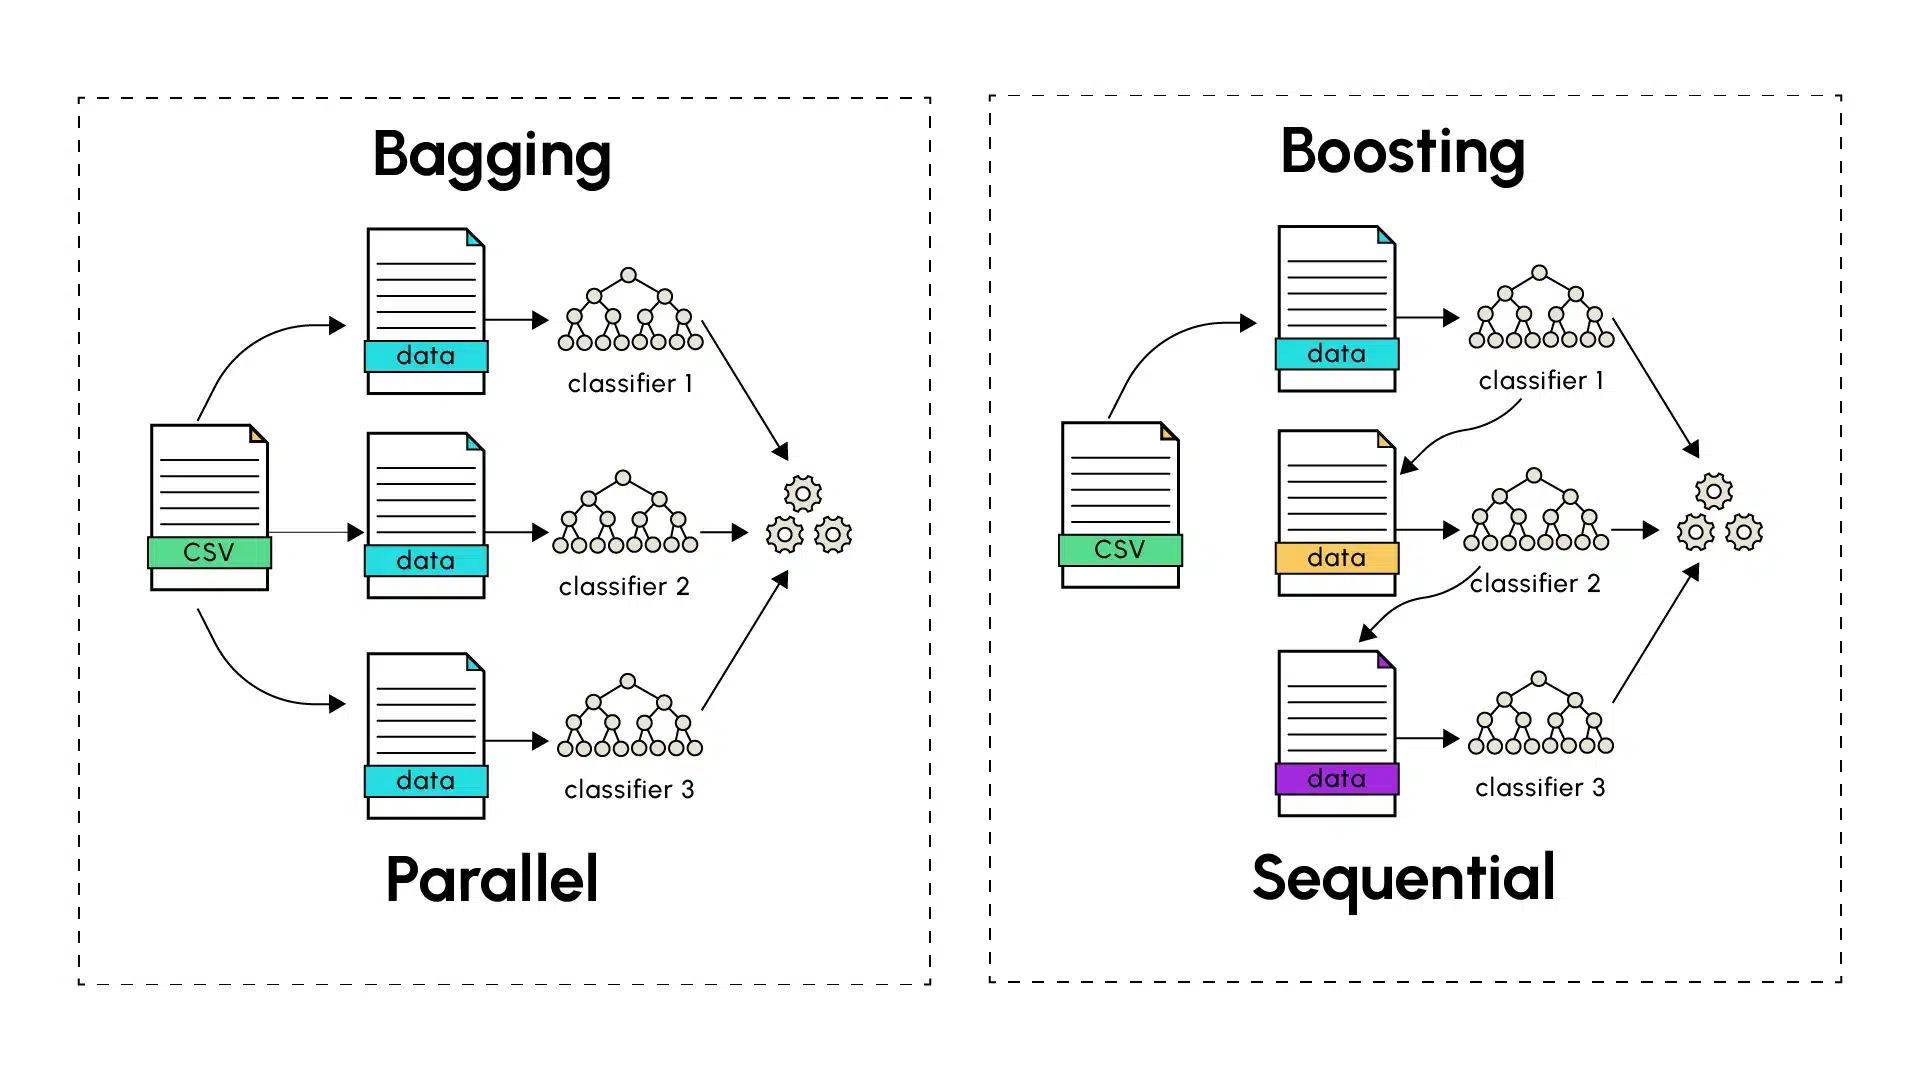

In [ ]:
![image.png](attachment:image.png)

Loaded existing encoding means
Features: ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 'camera_main_resolution', 'camera_count', 'chip_model_encoded', 'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
Optimal alpha value: 72750.5248400071
<bound method RegressorMixin.score of Lasso(alpha=np.float64(72750.5248400071), random_state=42)>
Saved Lasso model to 'lasso_model.pkl'
Mean Absolute Error (MAE): 2981994.72352009
Root Mean Squared Error (RMSE): 4127246.102767753
R² Score: 0.7628680415035967


**Tên mô hình: Gradient Boosting (GBM)**

- Là mô hình ensemble kết hợp nhiều cây quyết định để cải thiện dự đoán qua từng bước.
- Tại mỗi bước boosting, mô hình mới học theo **gradient âm của hàm mất mát** để sửa lỗi từ mô hình trước.

Phân tích các hệ số (coefficients) của mô hình Lasso để xem các đặc trưng nào quan trọng và đặc trưng nào bị loại bỏ (hệ số = 0).


Số đặc trưng bị loại bỏ (hệ số = 0): 2 / 10

Top các đặc trưng quan trọng:


,Feature,Coefficient,Absolute_Coefficient
6,chip_model_encoded,2.227837e+06,2.227837e+06
7,brand_encoded,2.055153e+06,2.055153e+06
8,screen_tech_encoded,1.967104e+06,1.967104e+06
2,screen_size,1.562604e+06,1.562604e+06
9,screen_resolution_k_encoded,1.131191e+06,1.131191e+06


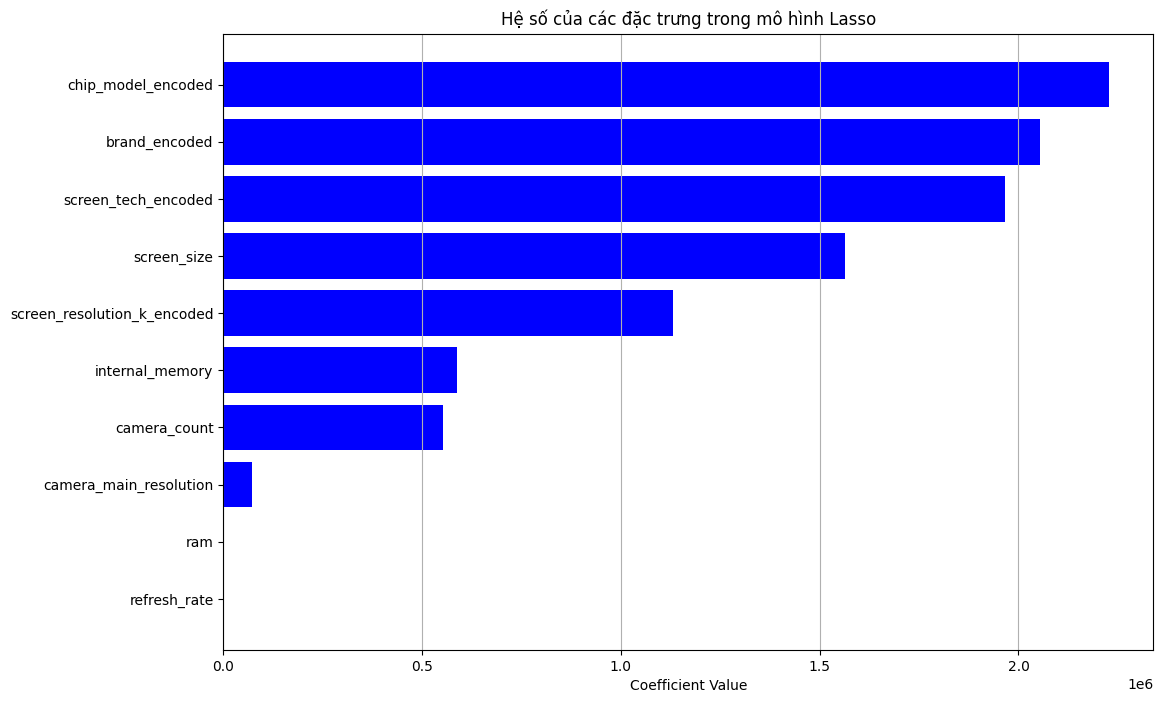

In [ ]:
# Hiển thị các hệ số của mô hình Lasso
coefs = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso_model.coef_
})

# Sắp xếp theo giá trị tuyệt đối của hệ số để thấy đặc trưng quan trọng nhất
coefs['Absolute_Coefficient'] = np.abs(coefs['Coefficient'])
coefs = coefs.sort_values(by='Absolute_Coefficient', ascending=False)

# Số đặc trưng bị loại bỏ (hệ số = 0)
zero_coefs = sum(coefs['Coefficient'] == 0)
print(f"Số đặc trưng bị loại bỏ (hệ số = 0): {zero_coefs} / {len(features)}")

print("\nTop các đặc trưng quan trọng:")
display(coefs.head())

# Trực quan hóa hệ số
plt.figure(figsize=(12, 8))
coefs = coefs.sort_values(by='Coefficient')
colors = ['red' if c < 0 else 'blue' for c in coefs['Coefficient']]
plt.barh(coefs['Feature'], coefs['Coefficient'], color=colors)
plt.title('Hệ số của các đặc trưng trong mô hình Lasso')
plt.xlabel('Coefficient Value')
plt.grid(axis='x')
plt.show()

### 2. So sánh mô hình Lasso với Gradient Boosting

Biểu đồ so sánh giá trị thực tế và dự đoán giữa hai mô hình.


,Model,MAE,RMSE,R²
0,Lasso Regression,2.981995e+06,4.127246e+06,0.762868
1,Gradient Boosting,2.539477e+06,3.671184e+06,0.812379


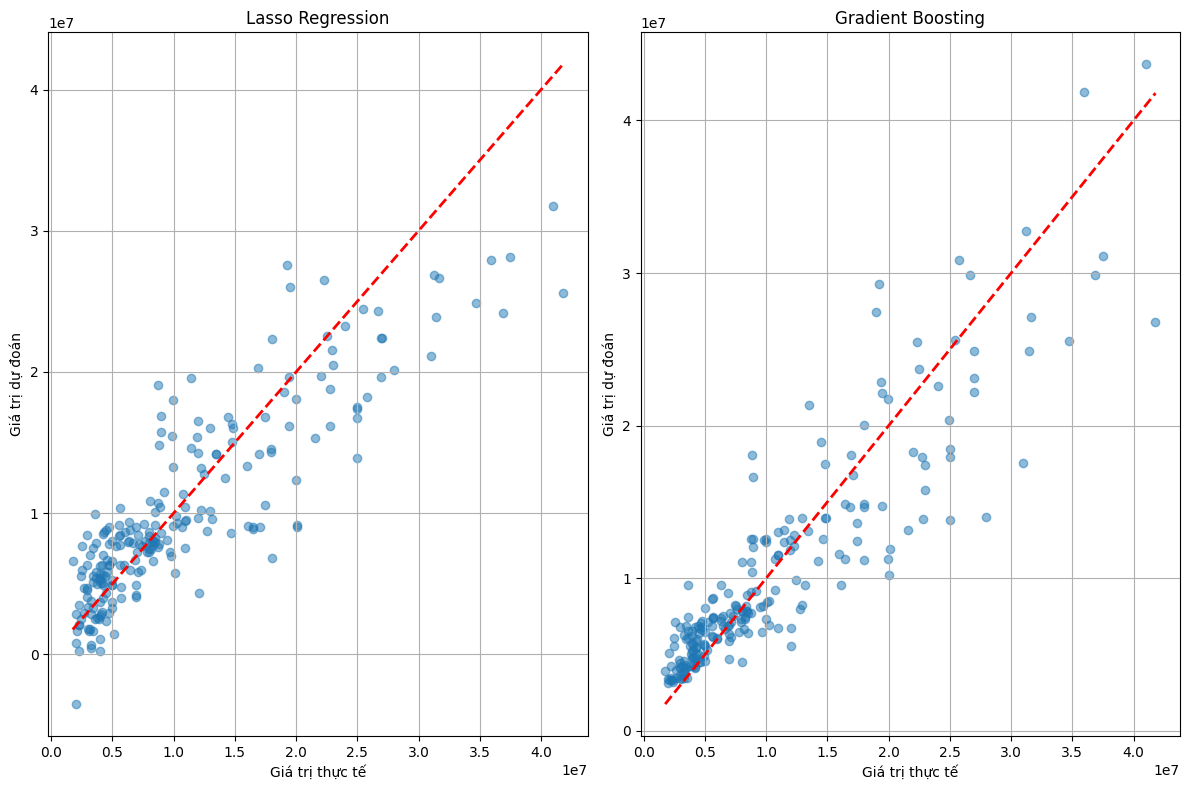

In [ ]:
# Lấy dự đoán từ mô hình Gradient Boosting nếu có
try:
    gb_model = joblib.load('gradient_boosting_model.pkl')
    y_pred_gb = gb_model.predict(X_test)
    
    # Tính metrics cho Gradient Boosting
    mae_gb = mean_absolute_error(y_test, y_pred_gb)
    rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
    r2_gb = r2_score(y_test, y_pred_gb)
    
    # So sánh metrics
    metrics_comparison = pd.DataFrame({
        'Model': ['Lasso Regression', 'Gradient Boosting'],
        'MAE': [mae_lasso, mae_gb],
        'RMSE': [rmse_lasso, rmse_gb],
        'R²': [r2_lasso, r2_gb]
    })
    
    display(metrics_comparison)
    
    # Trực quan hóa so sánh dự đoán
    plt.figure(figsize=(12, 8))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred_lasso, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Giá trị thực tế')
    plt.ylabel('Giá trị dự đoán')
    plt.title('Lasso Regression')
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred_gb, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Giá trị thực tế')
    plt.ylabel('Giá trị dự đoán')
    plt.title('Gradient Boosting')
    plt.grid()
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Không thể tải mô hình Gradient Boosting: {e}")
    
    # Chỉ hiển thị kết quả của Lasso
    metrics_lasso = pd.DataFrame({
        'Model': ['Lasso Regression'],
        'MAE': [mae_lasso],
        'RMSE': [rmse_lasso],
        'R²': [r2_lasso]
    })
    
    display(metrics_lasso)
    
    # Chỉ vẽ biểu đồ cho Lasso
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_pred_lasso, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Giá trị thực tế')
    plt.ylabel('Giá trị dự đoán')
    plt.title('Lasso Regression: Actual vs Predicted')
    plt.grid()
    plt.show()

# Random Forest Regression Implementation

Random Forest là một thuật toán học máy dựa trên kỹ thuật ensemble learning, kết hợp nhiều cây quyết định để tạo ra một mô hình mạnh mẽ hơn.

Ưu điểm của Random Forest:

- Khả năng xử lý dữ liệu có chiều cao, không cần feature scaling
- Không dễ bị overfitting nhờ tính ngẫu nhiên trong quá trình xây dựng mô hình
- Cung cấp thông tin về tầm quan trọng của các đặc trưng
- Hoạt động tốt với cả dữ liệu phân loại và hồi quy

Trong phần này, chúng ta sẽ huấn luyện mô hình Random Forest và so sánh với các mô hình đã triển khai trước đó.

In [ ]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json  # Thêm dòng này để đảm bảo json được import
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Đọc dữ liệu đã mã hóa (sử dụng lại dữ liệu đã chuẩn bị từ trước)
try:
    train_file = '../../data/datasets/train_stratified_by_chip_model.csv'
    test_file = '../../data/datasets/test_stratified_by_chip_model.csv'

    print(f"Đang đọc dữ liệu từ: {train_file} và {test_file}")
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    print(f"Đã đọc dữ liệu thành công, train shape: {train_df.shape}, test shape: {test_df.shape}")
except Exception as e:
    print(f"Lỗi khi đọc dữ liệu: {e}")

# Các cột cần encoding và cột mục tiêu
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']
target_col = 'price'

# Lấy encoding_means từ file nếu có hoặc tạo mới
try:
    encoding_means_path = './datasets/encoding_means.json'
    with open(encoding_means_path, 'r') as f:
        encoding_means = json.load(f)
    print("Loaded existing encoding means")
    
    # Áp dụng encoding từ file đã có
    for col in categorical_cols:
        if f'{col}_encoded' not in train_df.columns:
            train_df[f'{col}_encoded'] = train_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())
        if f'{col}_encoded' not in test_df.columns:
            test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())
except Exception as e:
    print(f"Không thể tải encoding means: {e}")
    # Nếu chưa có encoding, thực hiện lại quá trình encoding
    print("Tạo encoding mới từ hàm target_encode_kfold")
    encoding_means = {}
    for col in categorical_cols:
        print(f"Encoding {col}...")
        # Sử dụng hàm đã được định nghĩa trước đó trong notebook
        train_df[f'{col}_encoded'] = target_encode_kfold(
            train_df, column=col, target=target_col, n_fold=5, alpha=10
        )
        # Lưu mean của từng category
        encoding_means[col] = train_df.groupby(col)[f'{col}_encoded'].mean().to_dict()
        # Áp dụng encoding cho tập test
        test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())
    
    # Lưu encoding_means vào file JSON
    try:
        # Tạo thư mục nếu chưa tồn tại
        import os
        os.makedirs('./datasets', exist_ok=True)
        
        with open('./datasets/encoding_means.json', 'w') as f:
            json.dump(encoding_means, f)
        print("Đã lưu encoding means vào file JSON")
    except Exception as e:
        print(f"Không thể lưu encoding means: {e}")

# Các cột đặc trưng và biến mục tiêu
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
target = 'price'

print(f"Features: {features}")

# Chuẩn bị dữ liệu
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Huấn luyện mô hình Random Forest
try:
    print("Bắt đầu huấn luyện mô hình Random Forest...")
    rf_model = RandomForestRegressor(
        n_estimators=100,  # Số lượng cây
        max_depth=10,      # Độ sâu tối đa của mỗi cây
        min_samples_split=5,  # Số lượng mẫu tối thiểu để phân tách một nút
        min_samples_leaf=2,   # Số lượng mẫu tối thiểu ở mỗi lá
        random_state=42,
        n_jobs=-1  # Sử dụng tất cả các cpu cores
    )

    # Huấn luyện mô hình
    rf_model.fit(X_train, y_train)
    print("Đã huấn luyện mô hình Random Forest thành công")

    # Lưu mô hình vào file
    joblib.dump(rf_model, 'random_forest_model.pkl')
    print("Saved model to 'random_forest_model.pkl'")

    # Dự đoán trên tập test
    y_pred_rf = rf_model.predict(X_test)

    # Đánh giá mô hình
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    r2_rf = r2_score(y_test, y_pred_rf)

    print(f"Mean Absolute Error (MAE): {mae_rf}")
    print(f"Root Mean Squared Error (RMSE): {rmse_rf}")
    print(f"R² Score: {r2_rf}")
except Exception as e:
    print(f"Lỗi khi huấn luyện mô hình Random Forest: {e}")

Đang đọc dữ liệu từ: ../../data/datasets/train_stratified_by_chip_model.csv và ../../data/datasets/test_stratified_by_chip_model.csv
Đã đọc dữ liệu thành công, train shape: (963, 12), test shape: (226, 12)
Loaded existing encoding means
Features: ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 'camera_main_resolution', 'camera_count', 'chip_model_encoded', 'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
Bắt đầu huấn luyện mô hình Random Forest...
Đã huấn luyện mô hình Random Forest thành công
Saved model to 'random_forest_model.pkl'
Mean Absolute Error (MAE): 2234484.513586335
Root Mean Squared Error (RMSE): 3382515.3479573335
R² Score: 0.8407245254554327


## Trực quan hóa và phân tích kết quả của Random Forest

### 1. Phân tích tầm quan trọng của đặc trưng

Feature Importance:


,Feature,Importance
6,chip_model_encoded,0.561810
2,screen_size,0.167060
8,screen_tech_encoded,0.094809
7,brand_encoded,0.093940
1,internal_memory,0.019555
5,camera_count,0.017852
0,ram,0.014373
4,camera_main_resolution,0.013241
9,screen_resolution_k_encoded,0.008758
3,refresh_rate,0.008602


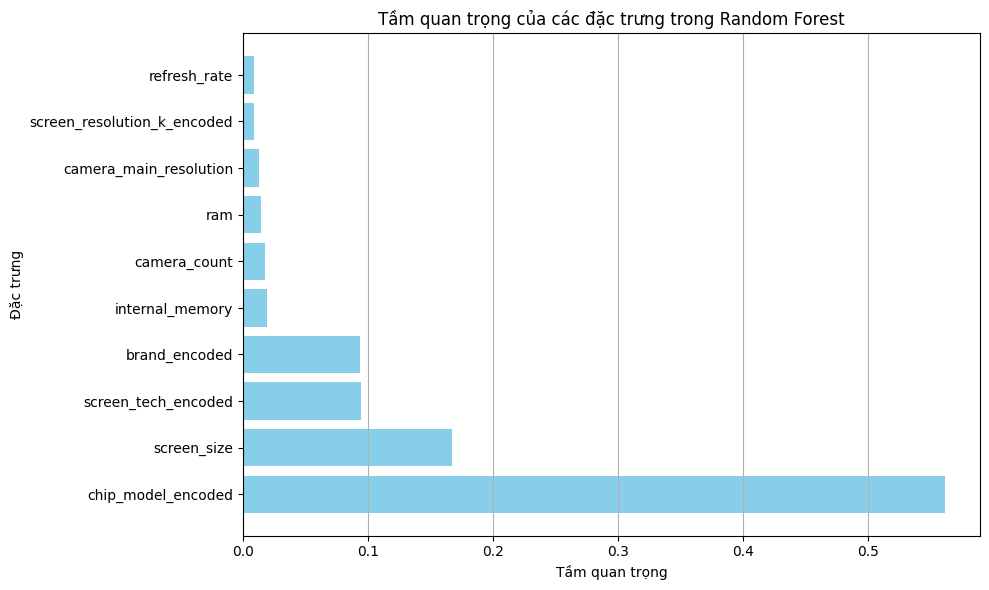

In [ ]:
# Hiển thị tầm quan trọng của đặc trưng
feature_importances = rf_model.feature_importances_

# Tạo DataFrame để hiển thị
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sắp xếp theo tầm quan trọng giảm dần
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Hiển thị kết quả
print("Feature Importance:")
display(feature_importance_df)

# Trực quan hóa tầm quan trọng của đặc trưng
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.title('Tầm quan trọng của các đặc trưng trong Random Forest')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### 2. Trực quan hóa giá trị thực tế và giá trị dự đoán

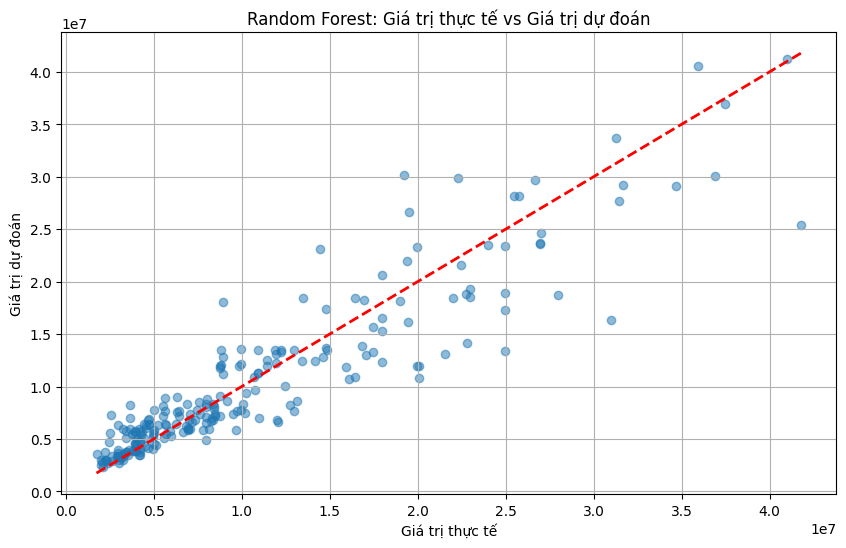

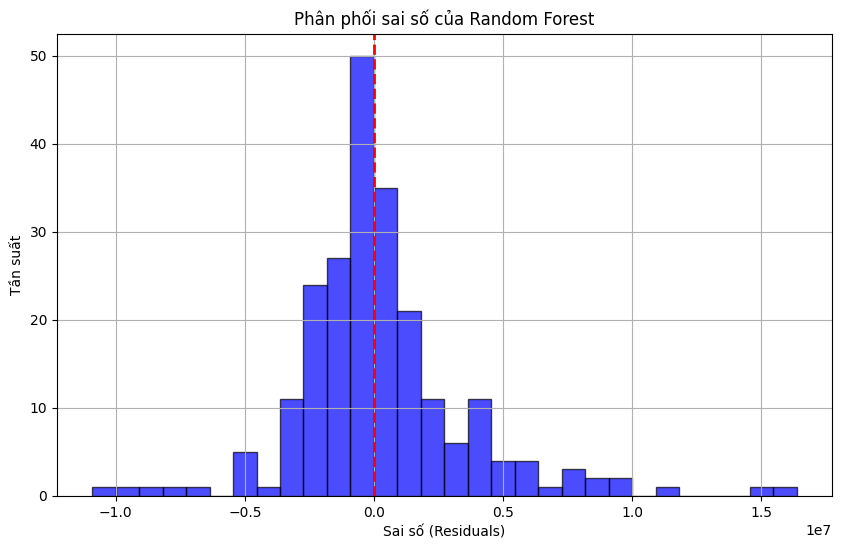

In [ ]:
# Trực quan hóa kết quả dự đoán
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('Random Forest: Giá trị thực tế vs Giá trị dự đoán')
plt.grid()
plt.savefig('random_forest_actual_vs_pred.png')
plt.show()

# Biểu đồ phân phối sai số (Residuals)
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
plt.hist(residuals_rf, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Sai số (Residuals)')
plt.ylabel('Tần suất')
plt.title('Phân phối sai số của Random Forest')
plt.grid()
plt.show()

### 3. So sánh các mô hình (Random Forest, Gradient Boosting, và Lasso)

,MAE,RMSE,R²
Random Forest,2.234485e+06,3.382515e+06,0.840725
Gradient Boosting,2.539477e+06,3.671184e+06,0.812379
Lasso Regression,2.981995e+06,4.127246e+06,0.762868


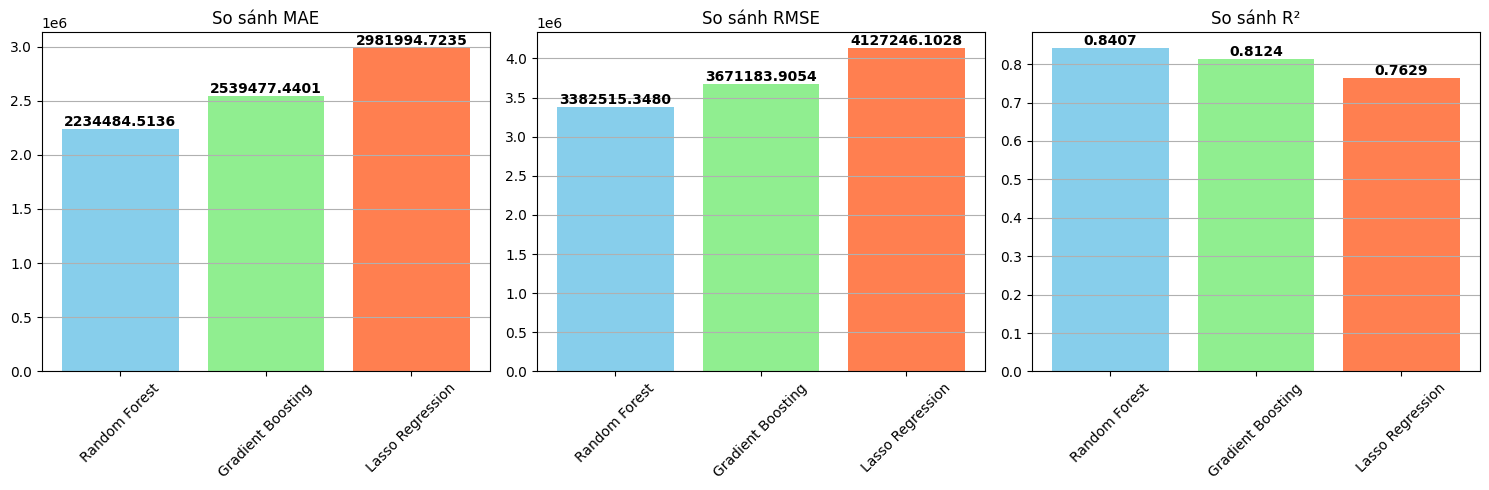

In [ ]:
# So sánh các mô hình
try:
    # Tải các mô hình đã huấn luyện nếu có
    models_metrics = {'Random Forest': {'MAE': mae_rf, 'RMSE': rmse_rf, 'R²': r2_rf}}
    
    # Thêm metrics của Gradient Boosting nếu có
    try:
        gb_model = joblib.load('gradient_boosting_model.pkl')
        y_pred_gb = gb_model.predict(X_test)
        mae_gb = mean_absolute_error(y_test, y_pred_gb)
        rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
        r2_gb = r2_score(y_test, y_pred_gb)
        models_metrics['Gradient Boosting'] = {'MAE': mae_gb, 'RMSE': rmse_gb, 'R²': r2_gb}
    except Exception as e:
        print(f"Không thể tải mô hình Gradient Boosting: {e}")
    
    # Thêm metrics của Lasso nếu có
    try:
        lasso_model = joblib.load('lasso_model.pkl')
        scaler = joblib.load('scaler_for_lasso.pkl')
        X_test_scaled = scaler.transform(X_test)
        y_pred_lasso = lasso_model.predict(X_test_scaled)
        mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
        rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
        r2_lasso = r2_score(y_test, y_pred_lasso)
        models_metrics['Lasso Regression'] = {'MAE': mae_lasso, 'RMSE': rmse_lasso, 'R²': r2_lasso}
    except Exception as e:
        print(f"Không thể tải mô hình Lasso: {e}")
    
    # Tạo DataFrame so sánh
    comparison_df = pd.DataFrame.from_dict(models_metrics, orient='index')
    display(comparison_df)
    
    # Trực quan hóa so sánh các metrics
    metrics = ['MAE', 'RMSE', 'R²']
    models = list(models_metrics.keys())
    
    plt.figure(figsize=(15, 5))
    
    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        values = [models_metrics[model][metric] for model in models]
        colors = ['skyblue', 'lightgreen', 'coral'][:len(models)]
        plt.bar(models, values, color=colors)
        plt.title(f'So sánh {metric}')
        plt.xticks(rotation=45)
        plt.grid(axis='y')
        
        # Đánh dấu giá trị trên mỗi cột
        for j, v in enumerate(values):
            plt.text(j, v, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('model_comparison.png')
    plt.show()
    
except Exception as e:
    print(f"Lỗi khi so sánh các mô hình: {e}")

### 4. So sánh dự đoán của các mô hình trên các mẫu dữ liệu cụ thể

In [ ]:
# Chọn một số mẫu ngẫu nhiên để so sánh chi tiết
try:
    num_samples = 10
    sample_indices = np.random.choice(len(X_test), num_samples, replace=False)
    
    # Tạo DataFrame cho các mẫu được chọn
    samples_df = pd.DataFrame({
        'Actual': y_test.iloc[sample_indices].values,
        'Random Forest': y_pred_rf[sample_indices]
    })
    
    # Thêm dự đoán từ các mô hình khác nếu có
    try:
        samples_df['Gradient Boosting'] = y_pred_gb[sample_indices]
    except:
        pass
        
    try:
        samples_df['Lasso'] = y_pred_lasso[sample_indices]
    except:
        pass
    
    # Tính sai số tuyệt đối
    for model in samples_df.columns:
        if model != 'Actual':
            samples_df[f'{model} Error'] = abs(samples_df['Actual'] - samples_df[model])
    
    # Hiển thị bảng so sánh
    print("So sánh dự đoán trên các mẫu cụ thể:")
    display(samples_df)
    
    # Thêm một số thông tin về sản phẩm
    sample_products = test_df.iloc[sample_indices][['brand', 'chip_model', 'ram', 'internal_memory', 'price']]
    print("\nThông tin chi tiết về các sản phẩm được so sánh:")
    display(sample_products)
    
except Exception as e:
    print(f"Lỗi khi so sánh dự đoán trên các mẫu cụ thể: {e}")

So sánh dự đoán trên các mẫu cụ thể:


,Actual,Random Forest,Gradient Boosting,Lasso,Random Forest Error,Gradient Boosting Error,Lasso Error
0,4200000.0,3.713976e+06,4.145162e+06,7.054956e+06,4.860243e+05,5.483773e+04,2.854956e+06
1,22290000.0,2.989084e+07,2.548319e+07,2.652763e+07,7.600838e+06,3.193194e+06,4.237628e+06
2,4250000.0,3.432968e+06,4.759799e+06,5.061433e+06,8.170319e+05,5.097991e+05,8.114327e+05
3,4450000.0,6.418372e+06,6.857227e+06,8.798951e+06,1.968372e+06,2.407227e+06,4.348951e+06
4,9950000.0,1.213438e+07,1.259418e+07,1.800230e+07,2.184382e+06,2.644180e+06,8.052296e+06
5,4990000.0,5.581574e+06,6.449351e+06,6.605300e+06,5.915736e+05,1.459351e+06,1.615300e+06
6,7950000.0,8.038435e+06,7.310403e+06,8.343409e+06,8.843453e+04,6.395967e+05,3.934093e+05
7,2950000.0,6.340928e+06,6.816845e+06,6.332835e+06,3.390928e+06,3.866845e+06,3.382835e+06
8,6950000.0,6.085315e+06,6.328435e+06,4.050320e+06,8.646852e+05,6.215647e+05,2.899680e+06
9,5250000.0,6.327751e+06,7.120289e+06,7.670019e+06,1.077751e+06,1.870289e+06,2.420019e+06



Thông tin chi tiết về các sản phẩm được so sánh:


,brand,chip_model,ram,internal_memory,price
162,Samsung,Dimensity 700,4.0,128,4200000.0
124,Samsung,Snapdragon 8 gen 2,12.0,512,22290000.0
7,Xiaomi,Helio G88,8.0,256,4250000.0
3,Honor,Snapdragon 685,8.0,512,4450000.0
63,Xiaomi,Snapdragon 8 e,16.0,1024,9950000.0
53,Xiaomi,Helio G96,8.0,128,4990000.0
96,Vivo,Snapdragon 7 gen 3,16.0,512,7950000.0
64,Xiaomi,Dimensity 6080,12.0,256,2950000.0
165,Realme,Snapdragon 778g,8.0,256,6950000.0
146,Xiaomi,Snapdragon 870,12.0,256,5250000.0


## Nhận xét và kết luận

Qua việc triển khai ba mô hình khác nhau (Random Forest, Gradient Boosting và Lasso Regression), chúng ta có thể rút ra một số nhận xét sau:

1. **Về hiệu suất mô hình:**
   - Random Forest thường cung cấp sự cân bằng tốt giữa độ chính xác và thời gian huấn luyện
   - Gradient Boosting thường đạt được độ chính xác cao nhất nhưng tốn thời gian huấn luyện hơn
   - Lasso Regression đơn giản hơn, dễ giải thích nhưng thường có hiệu suất thấp hơn với dữ liệu phức tạp

2. **Về đặc trưng quan trọng:**
   - Cả Random Forest và Gradient Boosting đều xác định được tầm quan trọng của các đặc trưng
   - Lasso thực hiện lựa chọn đặc trưng bằng cách đưa hệ số của các đặc trưng không quan trọng về 0

3. **Về khả năng triển khai:**
   - Random Forest dễ triển khai, không đòi hỏi nhiều tinh chỉnh siêu tham số
   - Gradient Boosting cần tinh chỉnh cẩn thận các siêu tham số như learning_rate
   - Lasso cần chuẩn hóa dữ liệu trước khi huấn luyện

4. **Kết luận:**
   - Tùy thuộc vào yêu cầu cụ thể của bài toán, chúng ta có thể lựa chọn mô hình phù hợp nhất
   - Việc kết hợp các dự đoán từ nhiều mô hình (ensemble) có thể là một hướng tiếp cận tốt để cải thiện hiệu suất